In [1]:
!pip install --upgrade sympy

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.interpolate import griddata
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
print(np.__version__)
print(pd.__version__)

2.0.2
2.2.2


In [3]:
df = pd.read_csv('JUIndoorLoc-Training-data.csv')
df_test = pd.read_csv('JUIndoorLoc-Test-data.csv')
df.shape, df_test.shape

((23904, 177), (1460, 177))

In [4]:
split_cols = df['Cid'].str.lstrip('L').str.split('-', expand=True)
split_cols.head(3)

,0,1,2
0,4,40,1
1,4,40,1
2,4,40,1


In [5]:
# Step 2: Assign new columns
df['floor'] = split_cols[0].astype(int)  # floor as integer
df['X'] = split_cols[1].astype(int)      # X coordinate
df['Y'] = split_cols[2].astype(int)      # Y coordinate

In [6]:
split_cols = df_test['Cid'].str.lstrip('L').str.split('-', expand=True)

# Step 2: Assign new columns
df_test['floor'] = split_cols[0].astype(int)  # floor as integer
df_test['X'] = split_cols[1].astype(int)      # X coordinate
df_test['Y'] = split_cols[2].astype(int)      # Y coordinate

In [7]:
df['floor'].value_counts()

,count
floor,
4,18016
5,4300
3,1588


In [8]:
df_test['floor'].value_counts()

,count
floor,
4,1460


In [9]:
df_3rd_floor = df[df['floor'] == 3]
df_4th_floor = df[df['floor'] == 4]
df_5th_floor = df[df['floor'] == 5]

In [10]:
def plot_floor_data(floor_df, label):
    fig, ax = plt.subplots()
    ax.scatter(floor_df['X'], floor_df['Y'])
    ax.set_xlabel('X(m)')
    ax.set_ylabel('Y(m)')
    ax.set_title(label)
    plt.show()

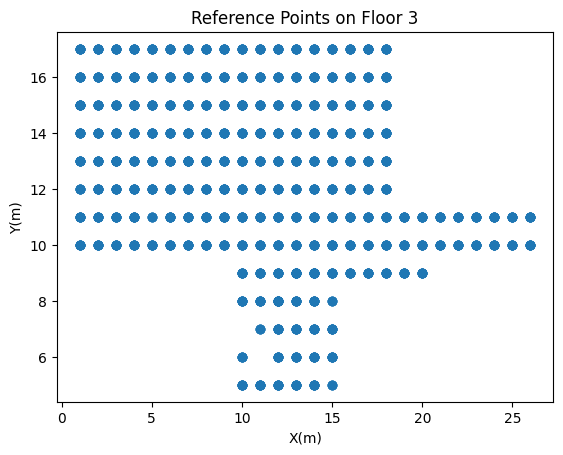

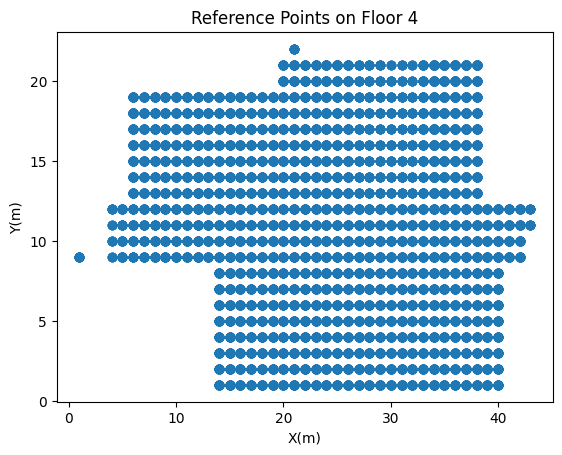

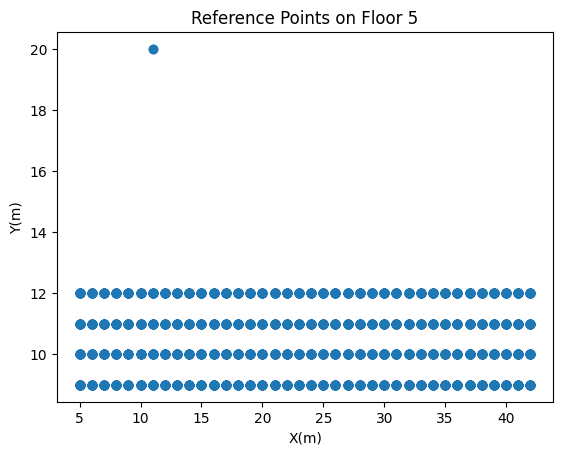

In [11]:
plot_floor_data(df_3rd_floor, "Reference Points on Floor 3")
plot_floor_data(df_4th_floor, "Reference Points on Floor 4")
plot_floor_data(df_5th_floor, "Reference Points on Floor 5")

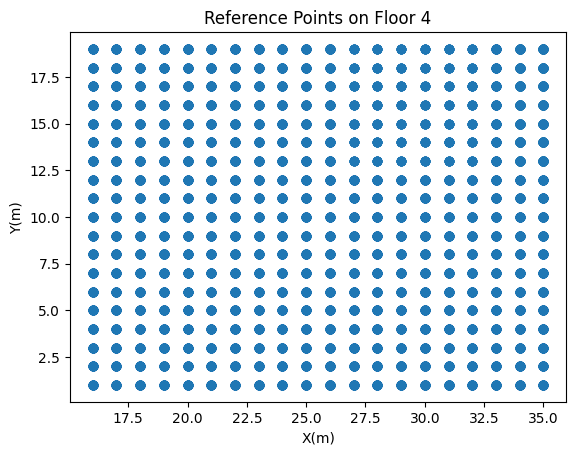

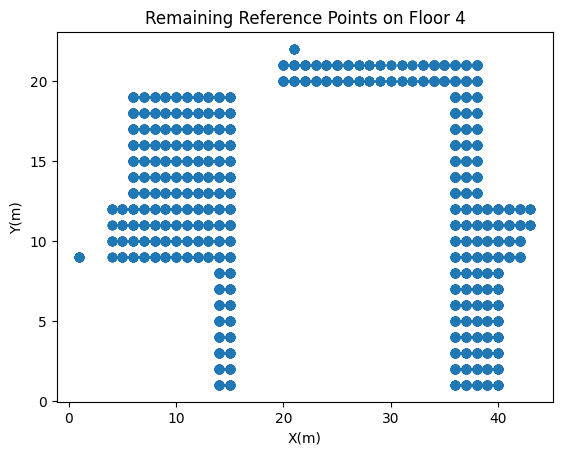

In [12]:
square_df = df_4th_floor[
    (df_4th_floor['X'] >= 16) & (df_4th_floor['X'] <= 35) & (df_4th_floor['Y'] >= 0) & (df_4th_floor['Y'] <= 19)]
remaining_df = df_4th_floor[
    ~((df_4th_floor['X'] >= 16) & (df_4th_floor['X'] <= 35) & (df_4th_floor['Y'] >= 0) & (df_4th_floor['Y'] <= 19))]
plot_floor_data(square_df, "Reference Points on Floor 4")
plot_floor_data(remaining_df, "Remaining Reference Points on Floor 4")


In [13]:
square_df.head(3)

,Cid,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,AP009,...,AP170,AP171,AP172,Rs,Hpr,Did,Ts,floor,X,Y
256,L4-34-1,-80,-81,-70,-63,-85,-75,-69,-110,-110,...,-110,-110,-110,0,0,D4,1469963153060,4,34,1
257,L4-34-1,-80,-81,-70,-63,-85,-75,-69,-110,-110,...,-110,-110,-110,0,0,D4,1470139819109,4,34,1
258,L4-34-1,-80,-80,-70,-63,-85,-75,-69,-110,-110,...,-110,-110,-110,0,0,D4,1469962304939,4,34,1


## Null values analysis:

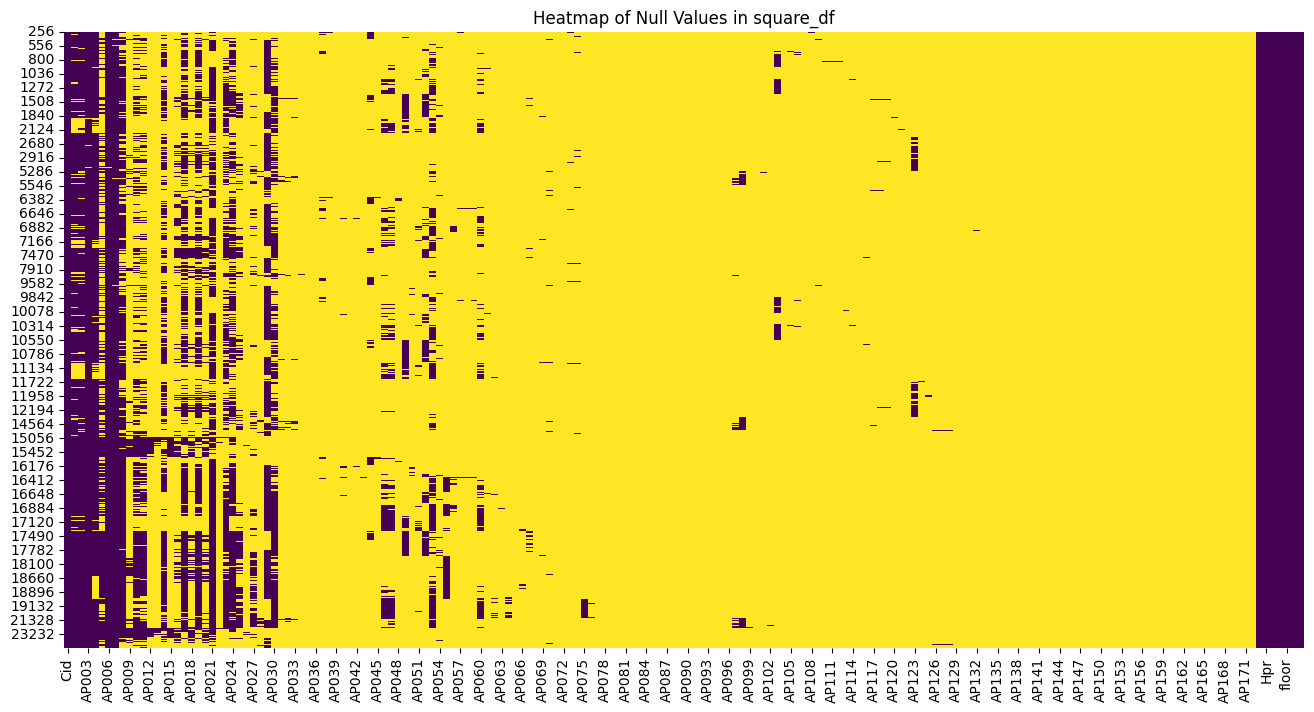

In [14]:
square_df = square_df.replace(-110, np.nan)
plt.figure(figsize=(16, 8))
sns.heatmap(square_df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Null Values in square_df')
plt.show()

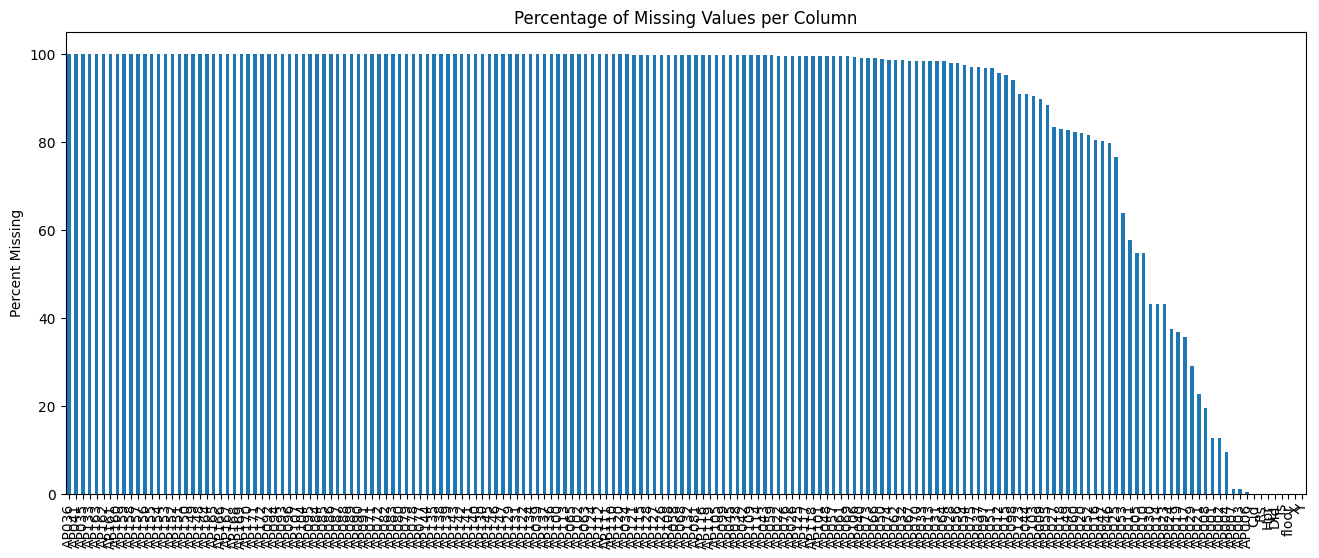

In [15]:
(square_df.isna().sum().sort_values(ascending=False) / len(square_df) * 100).plot(kind='bar', figsize=(16, 6), ylabel='Percent Missing')
plt.title('Percentage of Missing Values per Column')
plt.show()

In [16]:
print(f"Initial shape of the Dataset: {square_df.shape}")

Initial shape of the Dataset: (10379, 180)


In [17]:
null_percent = square_df.isna().sum() / len(square_df) * 100
cols_to_drop = null_percent[null_percent > 80].index
square_df_cleaned = square_df.drop(columns=cols_to_drop)
print(square_df_cleaned.info())

#-------------

null_percent_remaining_df = remaining_df.isna().sum() / len(remaining_df) * 100
cols_to_drop_remaining_df = null_percent_remaining_df[null_percent_remaining_df > 80].index
remaining_df_cleaned = remaining_df.drop(columns=cols_to_drop_remaining_df)
print(remaining_df_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
Index: 10379 entries, 256 to 23847
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Cid     10379 non-null  object 
 1   AP001   9065 non-null   float64
 2   AP002   9069 non-null   float64
 3   AP003   10263 non-null  float64
 4   AP004   9391 non-null   float64
 5   AP005   4690 non-null   float64
 6   AP006   10331 non-null  float64
 7   AP007   10257 non-null  float64
 8   AP008   8357 non-null   float64
 9   AP010   4696 non-null   float64
 10  AP011   4383 non-null   float64
 11  AP014   5904 non-null   float64
 12  AP017   6675 non-null   float64
 13  AP019   6559 non-null   float64
 14  AP021   8028 non-null   float64
 15  AP023   5909 non-null   float64
 16  AP024   6486 non-null   float64
 17  AP025   2429 non-null   float64
 18  AP029   7359 non-null   float64
 19  AP030   5903 non-null   float64
 20  AP046   2114 non-null   float64
 21  AP053   3747 non-null   float64
 22  R

In [18]:
print(f"Dataset after dropping columns: {square_df_cleaned.shape}")
print(f"Remaining dataset after dropping columns: {remaining_df_cleaned.shape}")

Dataset after dropping columns: (10379, 29)
Remaining dataset after dropping columns: (7637, 180)


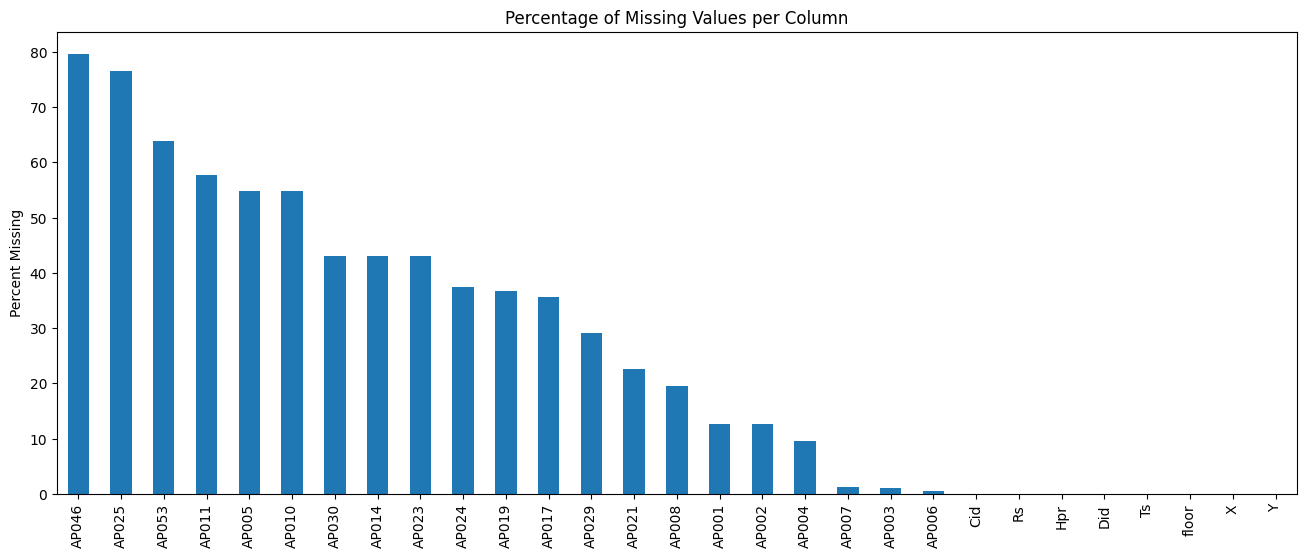

In [19]:
(square_df_cleaned.isna().sum().sort_values(ascending=False) / len(square_df_cleaned) * 100).plot(kind='bar', figsize=(16, 6), ylabel='Percent Missing')
plt.title('Percentage of Missing Values per Column')
plt.show()

In [20]:
# Feature Columns
def get_ap_columns(dataset):
    return [col for col in dataset.columns if col.startswith('AP')]

In [21]:
ap_cols = get_ap_columns(square_df_cleaned)
print(len(ap_cols))
print(ap_cols)

21
['AP001', 'AP002', 'AP003', 'AP004', 'AP005', 'AP006', 'AP007', 'AP008', 'AP010', 'AP011', 'AP014', 'AP017', 'AP019', 'AP021', 'AP023', 'AP024', 'AP025', 'AP029', 'AP030', 'AP046', 'AP053']


In [22]:
cond_cols = ['X','Y']

In [23]:
null_stats_ap_by_did = square_df_cleaned.groupby('Did')[ap_cols].apply(lambda group: group.isna().mean().mean() * 100)
print("Null Stats by Did:")
print(null_stats_ap_by_did)

Null Stats by Did:
Did
D1    39.206770
D2    23.799705
D3    40.755841
D4    40.916272
dtype: float64


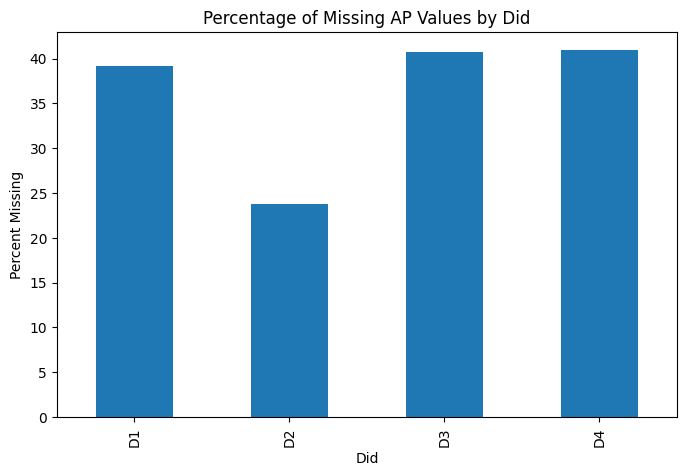

In [24]:
null_stats_ap_by_did.plot(kind='bar', figsize=(8, 5), ylabel='Percent Missing')
plt.title('Percentage of Missing AP Values by Did')
plt.show()

In [25]:
null_stats_ap_by_hpr = square_df_cleaned.groupby('Hpr')[ap_cols].apply(lambda group: group.isna().mean().mean() * 100)
print("Null Stats by Hpr:")
print(null_stats_ap_by_hpr)

Null Stats by Hpr:
Hpr
0    36.909046
1    33.898392
dtype: float64


In [26]:
null_stats_ap_by_rs = square_df_cleaned.groupby('Rs')[ap_cols].apply(lambda group: group.isna().mean().mean() * 100)
print("Null Stats by Rs:")
print(null_stats_ap_by_rs)

Null Stats by Rs:
Rs
0    36.104471
1    34.333220
dtype: float64


## Aggregation by mean

In [27]:
ap_mean_by_xy = square_df_cleaned.groupby(['X', 'Y'])[ap_cols].mean().reset_index()
print(ap_mean_by_xy.shape)
ap_mean_by_xy.head()

(380, 23)


,X,Y,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,...,AP017,AP019,AP021,AP023,AP024,AP025,AP029,AP030,AP046,AP053
0,16,1,-96.625,-87.5,-73.900000,NaN,NaN,-73.266667,-73.400000,-64.400000,...,NaN,NaN,-79.933333,-78.400000,NaN,NaN,-84.0,-78.800000,-81.000000,-76.066667
1,16,2,NaN,NaN,-65.892857,NaN,NaN,-63.821429,-63.500000,-63.285714,...,NaN,NaN,-73.928571,-73.142857,NaN,NaN,-90.0,-73.000000,-76.285714,-71.857143
2,16,3,NaN,NaN,-66.750000,NaN,NaN,-64.821429,-65.357143,-58.714286,...,-95.0,-96.0,-71.642857,-72.857143,-89.00,-96.0,-87.0,-73.642857,-75.571429,-72.285714
3,16,4,NaN,NaN,-60.857143,-96.5,NaN,-63.208333,-62.500000,-53.428571,...,-97.0,NaN,-71.230769,-73.857143,-89.25,-97.0,-90.0,-73.785714,-71.692308,-70.285714
4,16,5,-96.000,-91.5,-60.107143,-97.0,NaN,-59.392857,-57.857143,-57.642857,...,-95.0,-94.0,-68.000000,-76.928571,-96.00,-96.0,-83.0,-77.071429,-76.785714,-68.714286


## Heatmap plot

In [28]:
def plot_heatmap(dataset, feature):
    # Define grid
    xi = np.linspace(dataset['X'].min(), dataset['X'].max(), 200)
    yi = np.linspace(dataset['Y'].min(), dataset['Y'].max(), 200)
    xi, yi = np.meshgrid(xi, yi)

    # Interpolate (fill missing with nearest to avoid NaN holes)
    zi = griddata(
        (dataset['X'], dataset['Y']),
        dataset[feature],
        (xi, yi),
        method='cubic'
    )

    # Replace NaNs with nearest neighbor interpolation
    zi_nearest = griddata(
        (dataset['X'], dataset['Y']),
        dataset[feature],
        (xi, yi),
        method='nearest'
    )
    zi[np.isnan(zi)] = zi_nearest[np.isnan(zi)]

    # Plot
    plt.figure(figsize=(8,6))
    c = plt.pcolormesh(xi, yi, zi, cmap='viridis', shading='auto')
    plt.colorbar(c, label=f'{feature} Signal Strength (dBm)')
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")
    plt.title(f"Noise Map for {feature} on 4th Floor")
    plt.show()

MEAN:


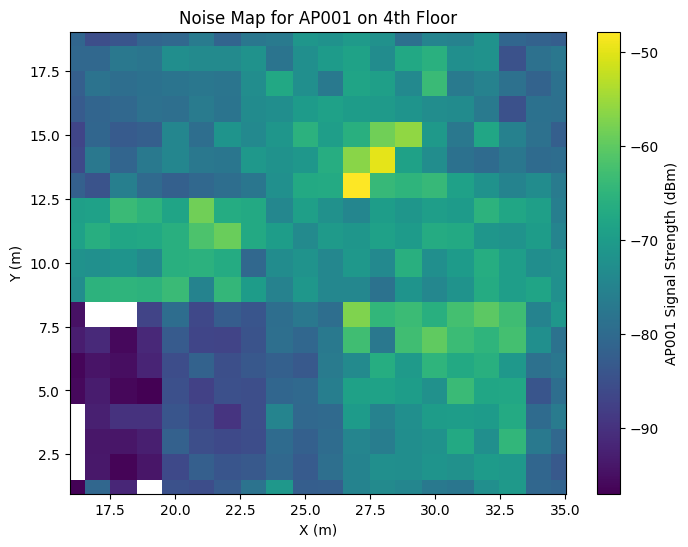

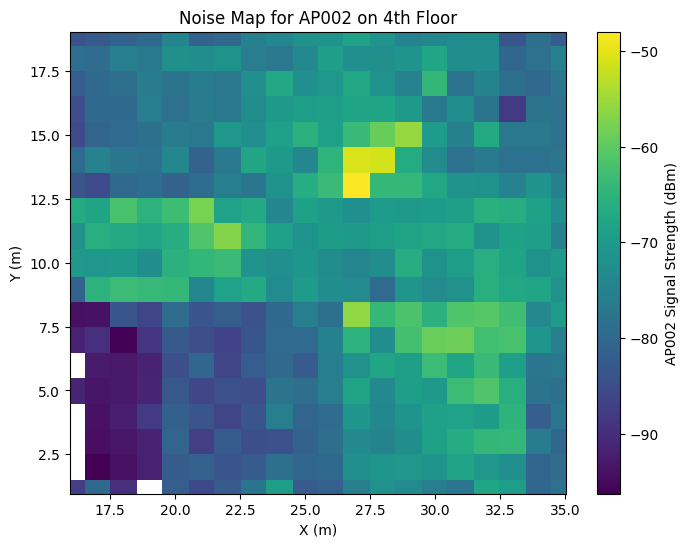

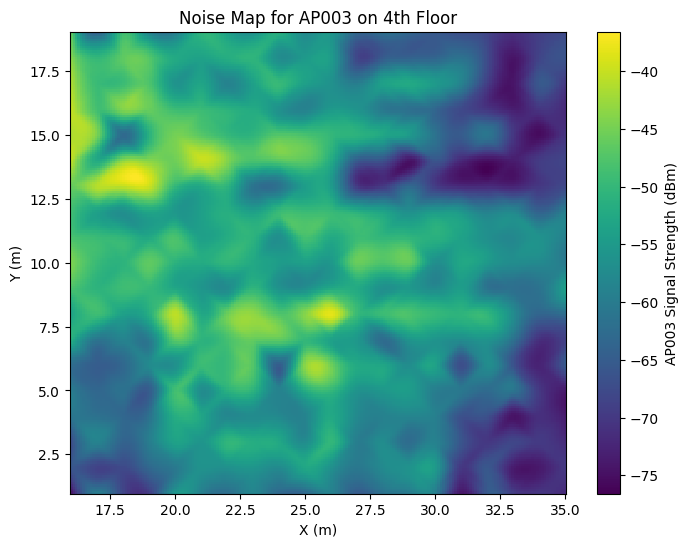

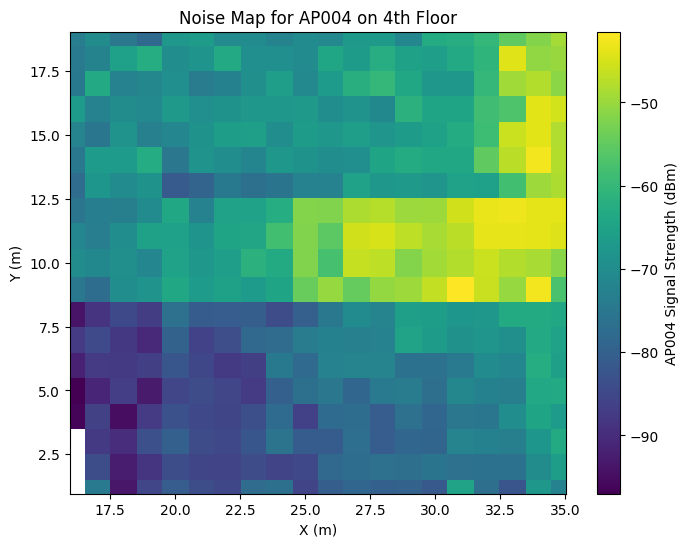

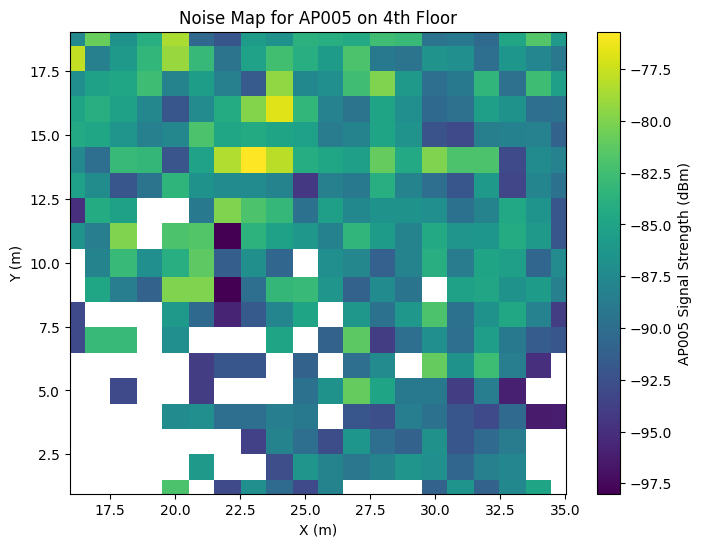

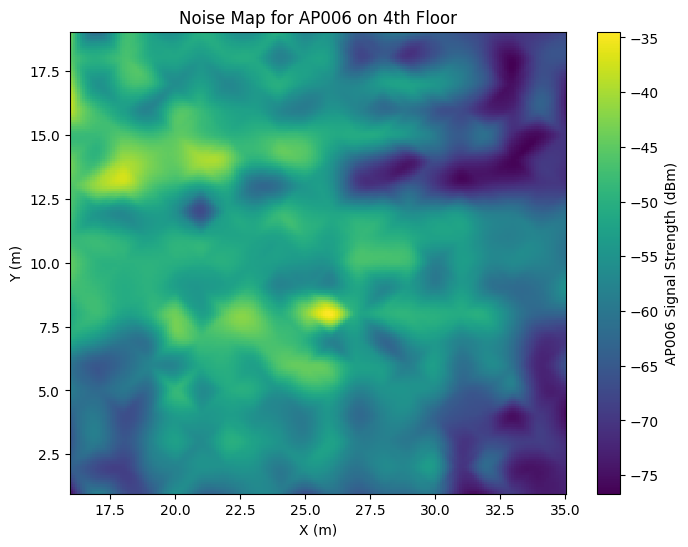

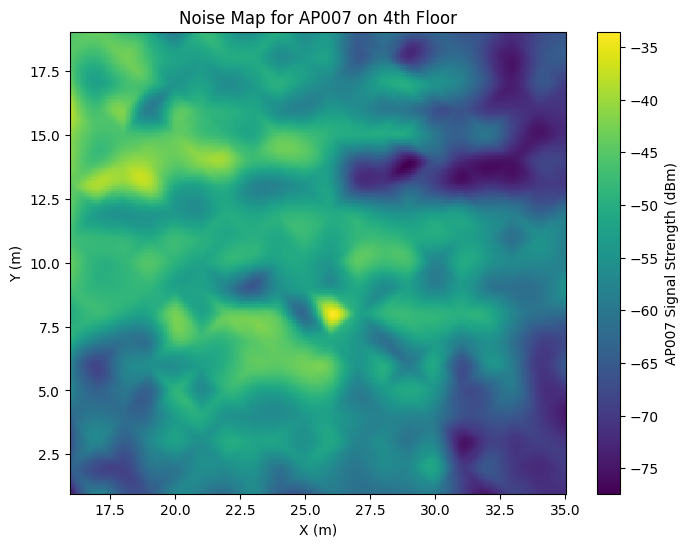

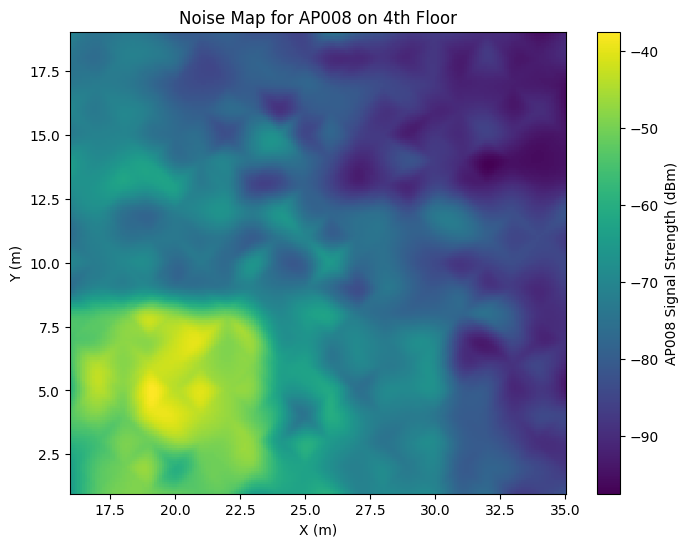

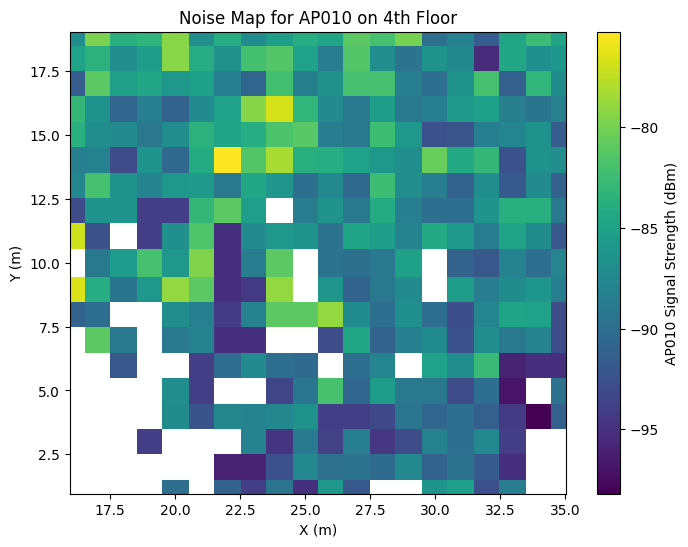

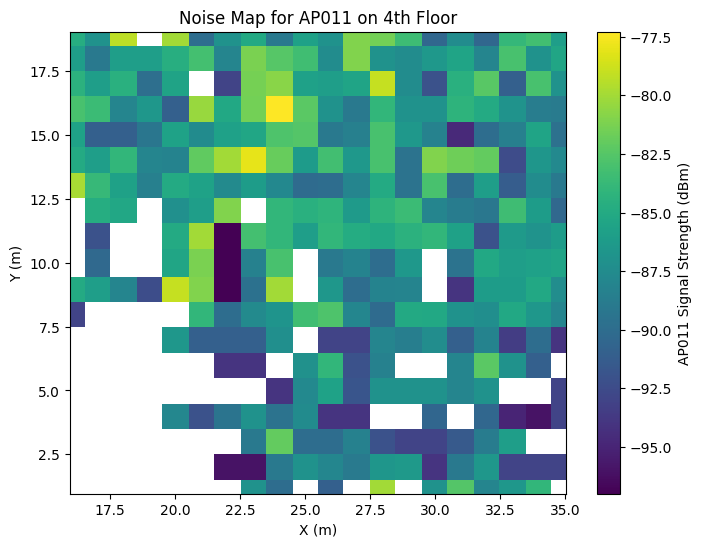

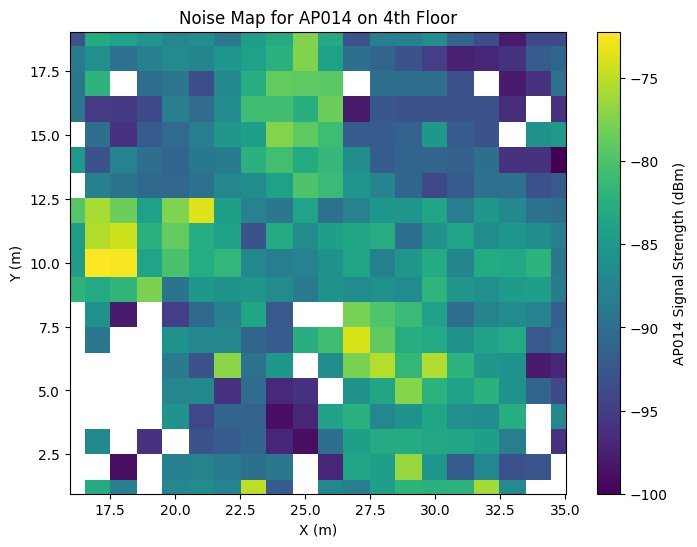

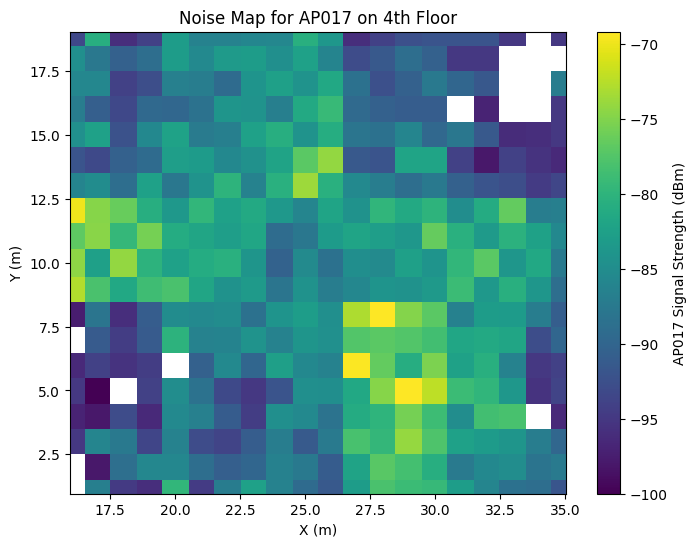

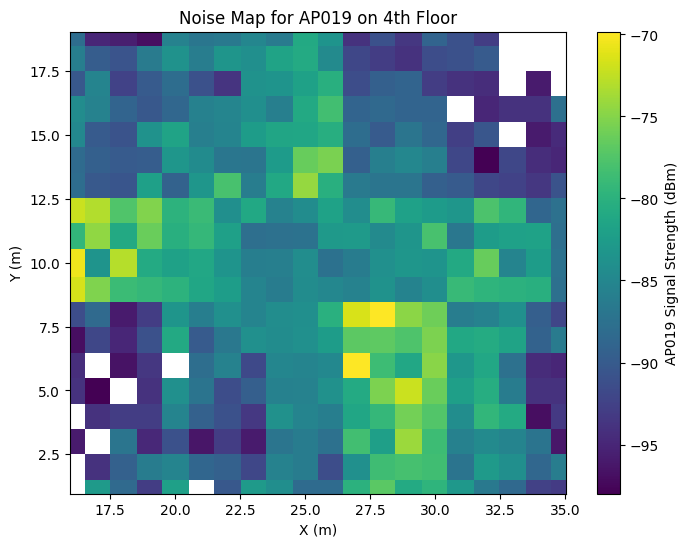

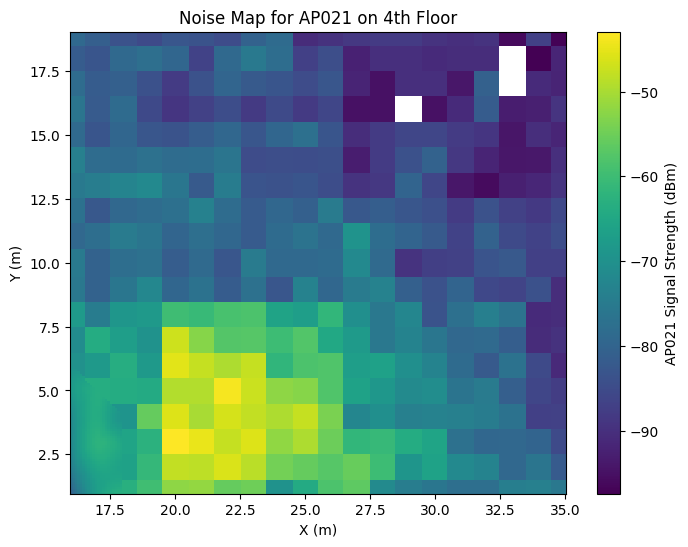

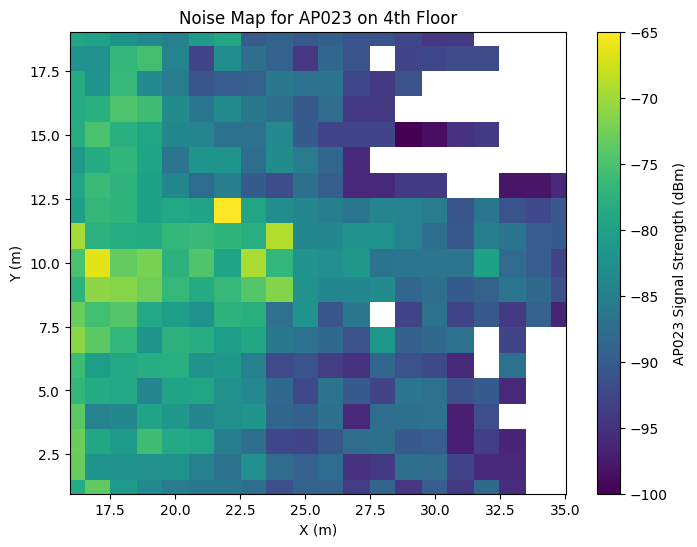

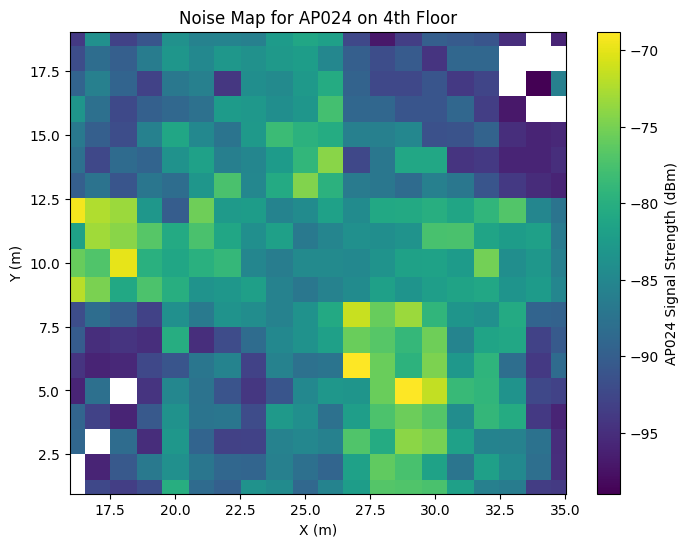

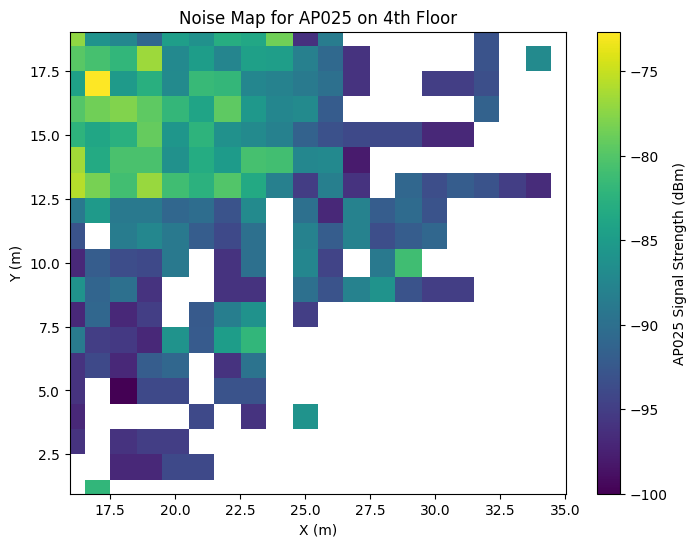

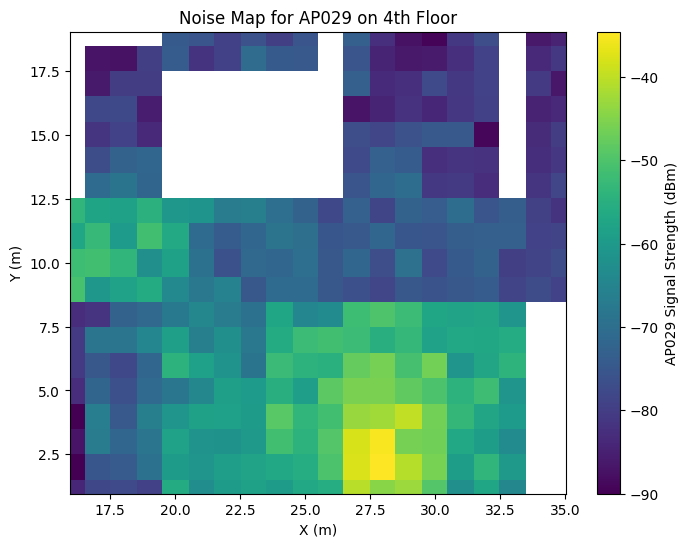

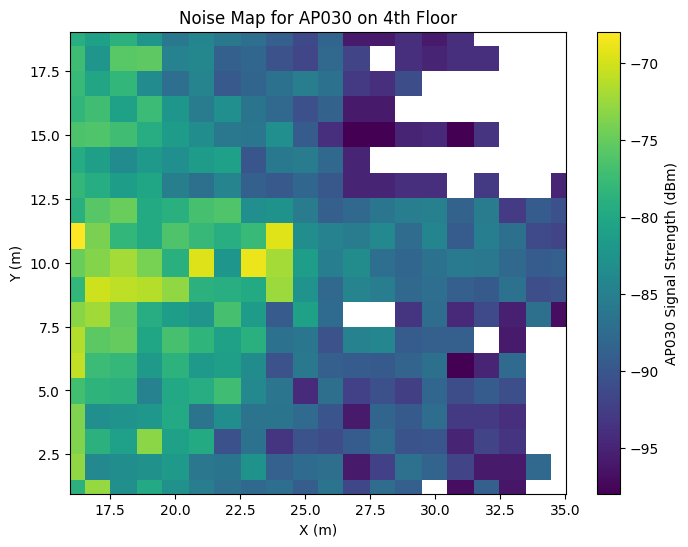

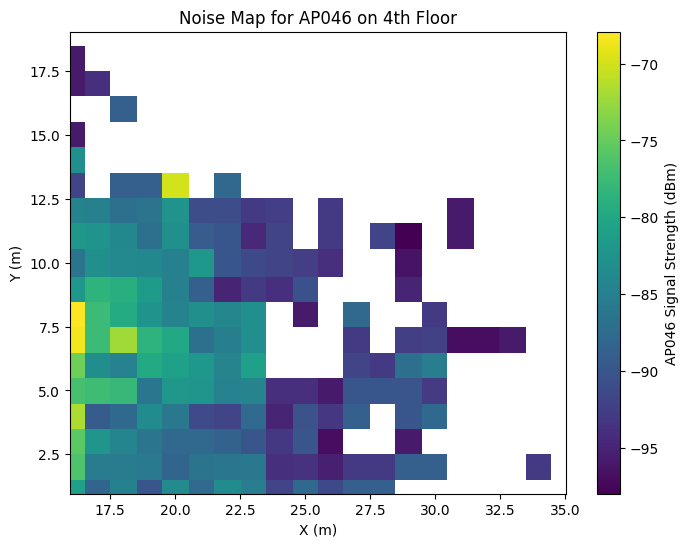

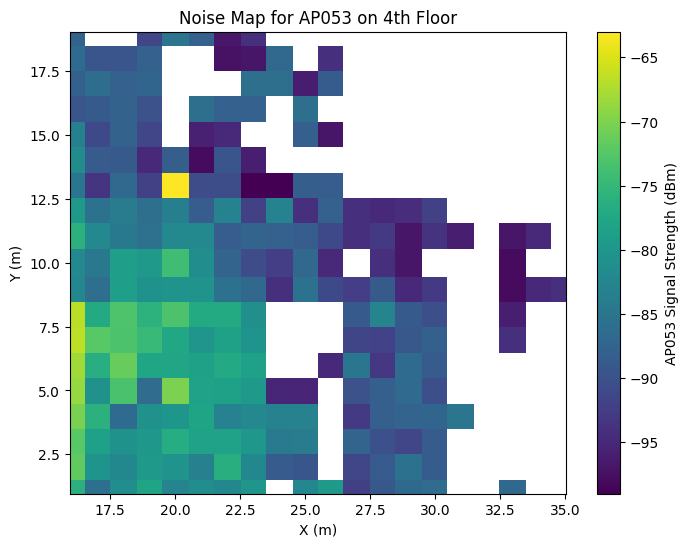

In [29]:
print("MEAN:")
for ap_col in ap_cols:
    plot_heatmap(ap_mean_by_xy, ap_col)

## Sampling Dataset Subset

In [30]:
def subsample_every_n(df, N, origin=(None,None), tol=1e-8):
    """
    Split df into two parts:
      • df_kept: rows where (X−x0) and (Y−y0) are multiples of N
      • df_rest: all the other rows

    Parameters
    ----------
    df : DataFrame with columns 'X','Y'
    N  : float           the grid spacing you want (e.g. 5.0)
    origin : (x0,y0)     the “zero” of your grid; if None, uses (min X, min Y)
    tol : float          tolerance for floating-point modulo

    Returns
    -------
    df_kept, df_rest : DataFrames
    """
    df2 = df.copy()

    # 1) determine grid origin
    x0 = origin[0] if origin[0] is not None else df2['X'].min()
    y0 = origin[1] if origin[1] is not None else df2['Y'].min()

    # 2) compute offsets
    dx = df2['X'] - x0
    dy = df2['Y'] - y0

    # 3) boolean mask for “on-grid” points
    on_grid = (
        np.isclose(dx.mod(N), 0.0, atol=tol) &
        np.isclose(dy.mod(N), 0.0, atol=tol)
    )

    # 4) split
    df_kept = df2.loc[on_grid].reset_index(drop=True)
    df_rest = df2.loc[~on_grid].reset_index(drop=True)

    return df_kept, df_rest

In [31]:
def fraction(actual, orig):
    return actual.shape[0] / orig.shape[0] * 100

## Table Diffusion Model

In [32]:
def get_beta(t: int, T: int) -> float:
    return (1.0 - math.cos(math.pi * t / T)) / 2.0

def timestep_embedding(timesteps: torch.Tensor, dim: int) -> torch.Tensor:
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=timesteps.device) / max(half - 1, 1))
    args = timesteps.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = nn.functional.pad(emb, (0, 1))
    return emb

# Tabular U-Net-like MLP backbone
class TabularUNet(nn.Module):
    def __init__(self, input_dim: int, cond_dim: int, time_emb_dim: int, hidden: list[int] = [512, 256, 128]):
        super().__init__()
        # Heads for time and condition
        self.t_proj = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, hidden[0])
        )
        self.c_proj = nn.Sequential(
            nn.Linear(cond_dim, hidden[0]),
            nn.SiLU()
        )

        # Encoder blocks
        enc_dims = [input_dim + hidden[0]*2] + hidden[:-1]
        self.encoder = nn.ModuleList(
            nn.Sequential(nn.Linear(i, o), nn.SiLU())
            for i, o in zip(enc_dims, hidden))

        # Decoder blocks
        dec_dims = hidden[::-1]
        self.decoder = nn.ModuleList(
            nn.Sequential(nn.Linear(i*2, o), nn.SiLU())
            for i, o in zip(dec_dims[:-1], dec_dims[1:]))

        # Final layer
        self.out = nn.Linear(hidden[0], input_dim)

    def forward(self, x: torch.Tensor, cond: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        # x: [batch, input_dim]
        # cond: [batch, cond_dim]
        # t_emb: [batch, time_emb_dim]
        t_h = self.t_proj(t_emb)
        c_h = self.c_proj(cond)

        h = torch.cat([x, c_h, t_h], dim=1)
        skips = []
        # Encode
        for enc in self.encoder:
            h = enc(h)
            skips.append(h)
        # Decode
        for dec in self.decoder:
            skip = skips.pop()
            h = torch.cat([h, skip], dim=1)
            h = dec(h)
        return self.out(h)

# Diffusion model with Tabular U-Net backbone
class TableDiffusion(nn.Module):
    def __init__(self, rss_dim: int, cond_dim: int = 2, time_emb_dim: int = 128, hidden: list[int] = [512, 256, 128]):
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.unet = TabularUNet(
            rss_dim,
            cond_dim,
            time_emb_dim,
            hidden
        )

    def forward(self, noised_rss: torch.Tensor, cond: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = timestep_embedding(t, self.time_emb_dim)
        return self.unet(noised_rss, cond, t_emb)


# Training loop (noise-prediction objective)
def train_table_diffusion(
    model: TableDiffusion,
    X_cond: torch.Tensor,
    Y_rss: torch.Tensor,
    steps: int = 100,
    batch_size: int = 64,
    epochs: int = 100,
    lr: float = 6e-4,
):
    device = (
        torch.device("mps") if torch.backends.mps.is_available()
        else torch.device("cuda") if torch.cuda.is_available()
        else torch.device("cpu")
    )
    print("Device:", device)
    model.to(device)
    ds = torch.utils.data.TensorDataset(X_cond, Y_rss)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    model.train()

    for ep in range(1, epochs+1):
        total = 0.0
        model.train()
        for cond_b, rss_b in dl:
            cond_b, rss_b = cond_b.to(device), rss_b.to(device)
            loss_acc = 0.0
            for t in range(steps):
                beta = get_beta(t, steps)
                noise = torch.randn_like(rss_b) * math.sqrt(beta)
                x_t = rss_b + noise
                t_vec = torch.full((rss_b.size(0),), t, dtype=torch.long, device=device)
                pred = model(x_t, cond_b, t_vec)
                loss_acc += mse(pred, noise)
            loss = loss_acc / steps
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item()
        if ep % 10 == 0 or ep == 1:
            print(f"[TableDiffusion] Epoch {ep}/{epochs} - loss: {total/len(dl):.4f}")
    return model

# Reverse sampling (denoise from Gaussian)
def sample_table_diffusion(
        model: TableDiffusion,
        X_cond: torch.Tensor,
        diffusion_steps: int = 100
) -> np.ndarray:
    device = (
    torch.device("mps") if torch.backends.mps.is_available()
        else torch.device("cuda") if torch.cuda.is_available()
        else torch.device("cpu")
    )
    print("Device:", device)
    model.eval()
    X_cond = X_cond.to(device)
    print(X_cond.shape)
    n, _ = X_cond.shape
    rss_dim = model.unet.out.out_features
    samples = torch.randn(n, rss_dim, device=device)

    with torch.no_grad():
        for t in reversed(range(diffusion_steps)):
            beta = get_beta(t, diffusion_steps)
            t_vec = torch.full((n,), t, dtype=torch.long, device=device)
            pred_eps = model(samples, X_cond, t_vec)
            samples = samples - pred_eps * math.sqrt(beta)
        return samples.cpu().numpy()

In [33]:
# Validation noise-prediction loss (quick proxy)
def eval_noise_mse(model, Xc, Yr, steps=50):
    device = next(model.parameters()).device
    mse = nn.MSELoss()
    model.eval()
    with torch.no_grad():
        Xc, Yr = Xc.to(device), Yr.to(device)
        tot = 0.0
        for t in range(steps):
            beta = get_beta(t, steps)
            eps = torch.randn_like(Yr) * math.sqrt(beta)
            x_t = Yr + eps
            t_vec = torch.full((Yr.size(0),), t, dtype=torch.long, device=device)
            pred = model(x_t, Xc, t_vec)
            tot += mse(pred, eps).item()
        return tot / steps


In [34]:
def train_tdm(dataset, ap_cols, cond_cols, steps=75, batch_size=64, epochs=200, lr=6.3e-4):
    # Replace missing APs with a sentinel before scaling
    td_train_filled = dataset.copy()
    td_train_filled[ap_cols] = td_train_filled[ap_cols].fillna(-110)

    # Train/val/test split
    X_cond = td_train_filled[cond_cols].values.astype("float32")
    Y_rss = td_train_filled[ap_cols].values.astype("float32")

    # Scale RSS targets only
    rss_scaler = StandardScaler()
    Y_rss_s = rss_scaler.fit_transform(Y_rss)

    print(f"Y_rss.shape: {Y_rss_s.shape}")

    # Tensors for X
    X_cond_t  = torch.tensor(X_cond,   dtype=torch.float32)
    # Tensors for Y
    Y_rss_t  = torch.tensor(Y_rss_s, dtype=torch.float32)

    # Instantiate, train, and demonstrate generation at custom coordinates
    rss_dim = len(ap_cols)
    td_model = TableDiffusion(rss_dim=rss_dim, cond_dim=2, time_emb_dim=128)

    td_model = train_table_diffusion(
        td_model,
        X_cond_t,
        Y_rss_t,
        steps=steps,          # can tune (e.g., 50–200)
        batch_size=batch_size,
        epochs=epochs,        # can tune
        lr=lr
    )

    val_noise_mse = eval_noise_mse(td_model, X_cond_t, Y_rss_t, steps=50)
    print(f"[TableDiffusion] Validation noise-prediction MSE: {val_noise_mse:.4f}")

    return td_model, X_cond_t, Y_rss_t, rss_scaler


In [35]:
def generate_rss_values(model, coords_dataset, rss_scaler, diffusion_steps=100):
    """
    Generate synthetic RSS values for the given condition columns.
    """

    gen_rss_values = sample_table_diffusion(model, coords_dataset, diffusion_steps)

    # Inverse transform to get the RSS values in the original scale
    synthetic_rss = rss_scaler.inverse_transform(gen_rss_values)

    synthetic_rss_df = pd.DataFrame(synthetic_rss, columns=ap_cols)
    return synthetic_rss_df

In [36]:
def generate_synthetic_rss(td_model, scaler, coordinates):
    coords_t = torch.tensor(coordinates.values,  dtype=torch.float32)
    synthetic_rss  = generate_rss_values(td_model, coords_t, scaler)

    synthetic_dataset = pd.concat([synthetic_rss, coordinates], axis=1)
    return synthetic_dataset

## KNN

In [37]:
def knn_regression(dataset):
    # Replace NaN with -110
    X_ap = dataset.drop(columns=cond_cols).fillna(-110).values
    y_xy = dataset[cond_cols].values

    scaler=StandardScaler()
    X_ap = scaler.fit_transform(X_ap)

    # KNN multi-output
    knn_xy = KNeighborsRegressor(
        n_neighbors=4,
        weights='distance',  # closer fingerprints count more
        metric='euclidean')
    knn_xy.fit(X_ap, y_xy)
    return knn_xy, scaler


In [38]:
def plot_indoor_localization_map(true_locations, predicted_locations_orig, predicted_locations_synth, title):
    plt.figure(figsize=(8,6))
    plt.scatter(true_locations[:,0], true_locations[:,1], c='yellow', marker='x',s=100, label="True locations")
    plt.scatter(predicted_locations_orig[:,0], predicted_locations_orig[:,1], c='b', alpha=0.5, label="KNN (model trained data)")
    plt.scatter(predicted_locations_synth[:,0], predicted_locations_synth[:,1], c='r', alpha=0.5, label="KNN (synthetic data)")
    # plt.scatter(pred_locations_combined[:,0], pred_locations_combined[:,1], c='g', alpha=0.5, label="KNN (combined data)")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.legend()
    plt.show()

In [39]:
def plot_indoor_localization_results(true_locations, predicted_locations, title):
    # Plotting
    plt.figure(figsize=(8, 6))

    # Scatter plots for the points
    plt.scatter(true_locations[:, 0], true_locations[:, 1], c='yellow', marker='x', s=100, label="True locations")
    plt.scatter(predicted_locations[:, 0], predicted_locations[:, 1], c='r', alpha=0.5, label="KNN (model trained data)")


    # Draw lines connecting the true points with synthetic predictions
    for i in range(len(true_locations)):
        plt.plot([true_locations[i, 0], predicted_locations[i, 0]],
                [true_locations[i, 1], predicted_locations[i, 1]],
                c='red', linestyle=':', linewidth=1)  # Lines between true and synthetic

    # Labels and title
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.legend()

    # Show the plot
    plt.show()

In [40]:
# Define a function to compute the Euclidean distance error.
def compute_localization_errors(true_locations, predicted_locations):
    errors = np.sqrt(np.sum((true_locations - predicted_locations)**2, axis=1))
    return errors

## Training and Model Evaluation

In [41]:
all_coords = ap_mean_by_xy[cond_cols]

In [42]:
print(ap_mean_by_xy.shape)
ap_mean_by_xy.head(3)

(380, 23)


,X,Y,AP001,AP002,AP003,AP004,AP005,AP006,AP007,AP008,...,AP017,AP019,AP021,AP023,AP024,AP025,AP029,AP030,AP046,AP053
0,16,1,-96.625,-87.5,-73.900000,NaN,NaN,-73.266667,-73.400000,-64.400000,...,NaN,NaN,-79.933333,-78.400000,NaN,NaN,-84.0,-78.800000,-81.000000,-76.066667
1,16,2,NaN,NaN,-65.892857,NaN,NaN,-63.821429,-63.500000,-63.285714,...,NaN,NaN,-73.928571,-73.142857,NaN,NaN,-90.0,-73.000000,-76.285714,-71.857143
2,16,3,NaN,NaN,-66.750000,NaN,NaN,-64.821429,-65.357143,-58.714286,...,-95.0,-96.0,-71.642857,-72.857143,-89.0,-96.0,-87.0,-73.642857,-75.571429,-72.285714


In [43]:
test_df, training_df = subsample_every_n(ap_mean_by_xy, 2, (0,0))

In [44]:
print(fraction(training_df, ap_mean_by_xy))
print(fraction(test_df, ap_mean_by_xy))

76.31578947368422
23.684210526315788


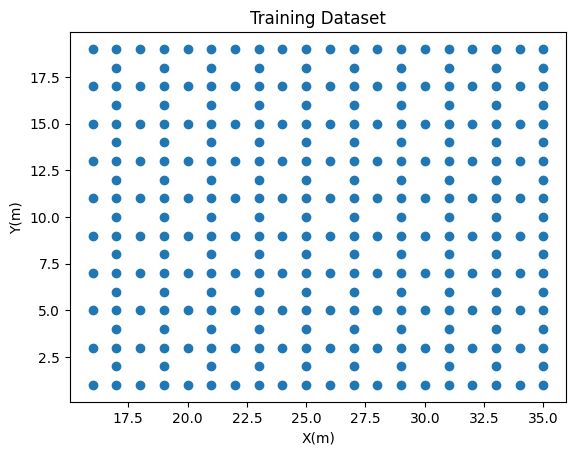

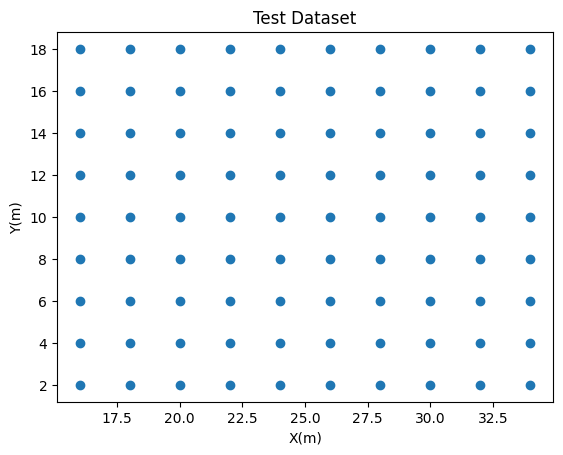

In [45]:
plot_floor_data(training_df, "Training Dataset")
plot_floor_data(test_df, "Test Dataset")

### Training TDDM

In [52]:
td_model, X_t, Y_t, scaler = train_tdm(training_df, ap_cols=get_ap_columns(training_df), cond_cols=cond_cols, epochs=4000, batch_size=64)

Y_rss.shape: (290, 21)
Device: cuda
[TableDiffusion] Epoch 1/4000 - loss: 0.5075
[TableDiffusion] Epoch 10/4000 - loss: 0.4734
[TableDiffusion] Epoch 20/4000 - loss: 0.5467
[TableDiffusion] Epoch 30/4000 - loss: 0.3884
[TableDiffusion] Epoch 40/4000 - loss: 0.2659
[TableDiffusion] Epoch 50/4000 - loss: 0.1875
[TableDiffusion] Epoch 60/4000 - loss: 0.1657
[TableDiffusion] Epoch 70/4000 - loss: 0.1522
[TableDiffusion] Epoch 80/4000 - loss: 0.1513
[TableDiffusion] Epoch 90/4000 - loss: 0.1502
[TableDiffusion] Epoch 100/4000 - loss: 0.1460
[TableDiffusion] Epoch 110/4000 - loss: 0.1419
[TableDiffusion] Epoch 120/4000 - loss: 0.1348
[TableDiffusion] Epoch 130/4000 - loss: 0.1337
[TableDiffusion] Epoch 140/4000 - loss: 0.1298
[TableDiffusion] Epoch 150/4000 - loss: 0.1319
[TableDiffusion] Epoch 160/4000 - loss: 0.1255
[TableDiffusion] Epoch 170/4000 - loss: 0.1264
[TableDiffusion] Epoch 180/4000 - loss: 0.1223
[TableDiffusion] Epoch 190/4000 - loss: 0.1200
[TableDiffusion] Epoch 200/4000 - l

In [53]:
synthetic_df = generate_synthetic_rss(td_model=td_model, scaler=scaler, coordinates=test_df[cond_cols])

Device: cuda
torch.Size([90, 2])


### KNN Evaluation

In [54]:
X_ap_train = training_df[get_ap_columns(training_df)].fillna(-110).values
y_xy_train = training_df[cond_cols].values

X_ap_test = test_df[get_ap_columns(test_df)].fillna(-110).values
y_xy_test = test_df[cond_cols].values

X_ap_synth = synthetic_df[get_ap_columns(synthetic_df)].fillna(-110).values
y_xy_synth = synthetic_df[cond_cols].values

In [58]:
from sklearn.model_selection import GridSearchCV

knn_scaler=StandardScaler()
X_ap_train_scaled = knn_scaler.fit_transform(X_ap_train)

# KNN multi-output
knn = KNeighborsRegressor(
    weights='distance',  # closer fingerprints count more
    metric='euclidean')

param_grid = {'n_neighbors': range(1, 31)}
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_ap_train_scaled, y_xy_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")

knn_best = grid_search.best_estimator_

pred_locations_synth = knn_best.predict(knn_scaler.transform(X_ap_synth))

Best parameters: {'n_neighbors': 3}
Best score: -11.116055517839516


In [59]:
np.mean(compute_localization_errors(y_xy_test, pred_locations_synth))

np.float64(1.0700027011394426)

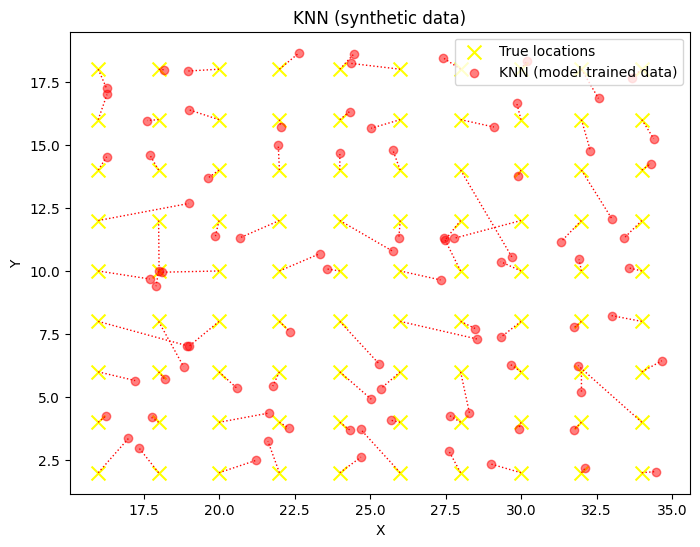

In [60]:
plot_indoor_localization_results(y_xy_test, pred_locations_synth, "KNN (synthetic data)")